In [47]:
import globals as gl

import os
import numpy as np
import sys

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import rsatoolbox as rsa


plt.close('all')
plt.style.use('default')


# Reliability (planning) #

Text(0, 0.5, 'Correlation')

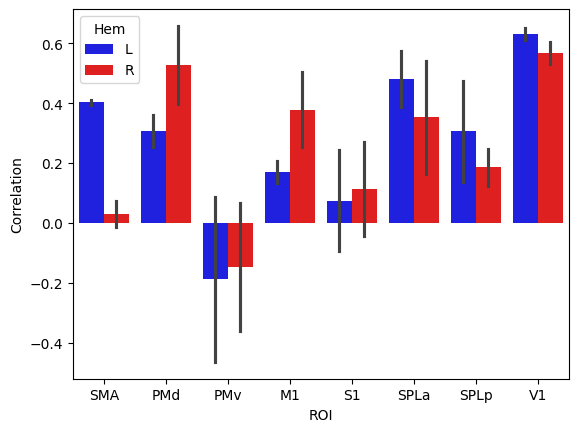

In [41]:
snS = [102, 103, 104]
experiment = 'smp2'
glm = 12

Y = list()
cond_vec = list()

corr = {
    'Hem': [],
    'ROI': [],
    'corr': [],
    'participant_id': []
}

for Hem in ['L', 'R']:
    for roi in gl.rois['ROI']:
        
        dist = list()
        for sn in snS:
            
            rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
            rdms = rdms.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
            dist_tmp = rdms.get_matrices()[0]
            n = dist_tmp.shape[0]
            idx = np.triu_indices(n, k=1)
            dist.append(dist_tmp[idx])
        
        dist = np.stack(dist)
        
        for i, sn in enumerate(snS):
            dist1 = dist[i]
            dist2 = np.delete(dist, i, axis=0).mean(axis=0)
            
            corr_tmp = np.corrcoef(dist1, dist2)[0, 1]
        
            corr['ROI'].append(roi)
            corr['Hem'].append(Hem)
            corr['corr'].append(corr_tmp)
            corr['participant_id'].append(f'subj{sn}')

fig, axs = plt.subplots()
sns.barplot(ax=axs, data=corr, y='corr', x='ROI', hue='Hem', errorbar='se', palette={'L': 'blue', 'R': 'red'},)
            
axs.set_ylabel('Correlation')


Text(0, 0.5, 'Correlation')

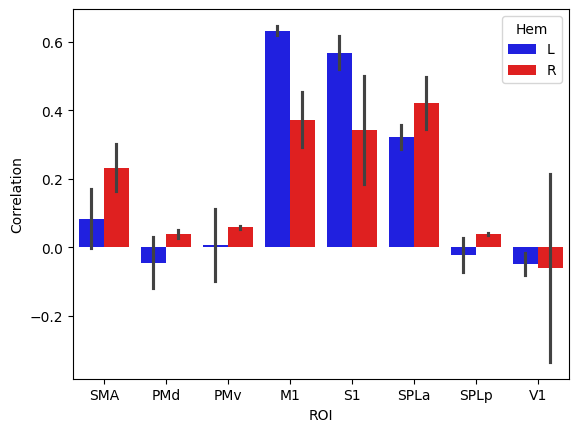

In [46]:
snS = [102, 103, 104]
experiment = 'smp2'
glm = 12

Y = list()
cond_vec = list()

corr = {
    'Hem': [],
    'ROI': [],
    'corr': [],
    'participant_id': []
}

for Hem in ['L', 'R']:
    for roi in gl.rois['ROI']:
        
        dist = list()
        for sn in snS:
            
            rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
            rdms = rdms.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index', '0%,ring', '25%,ring', '50%,ring', '75%,ring'])
            dist_tmp = rdms.get_matrices()[0]
            n = dist_tmp.shape[0]
            idx = np.triu_indices(n, k=1)
            dist.append(dist_tmp[idx])
        
        dist = np.stack(dist)
        
        for i, sn in enumerate(snS):
            dist1 = dist[i]
            dist2 = np.delete(dist, i, axis=0).mean(axis=0)
            
            corr_tmp = np.corrcoef(dist1, dist2)[0, 1]
        
            corr['ROI'].append(roi)
            corr['Hem'].append(Hem)
            corr['corr'].append(corr_tmp)
            corr['participant_id'].append(f'subj{sn}')

fig, axs = plt.subplots()
sns.barplot(ax=axs, data=corr, y='corr', x='ROI', hue='Hem', errorbar='se', palette={'L': 'blue', 'R': 'red'},)
            
axs.set_ylabel('Correlation')

Fitting Subj 0 model 0
Fitting Subj 0 model 1
Fitting Subj 0 model 2
Fitting Subj 0 model 3
Fitting Subj 0 model 4
Fitting Subj 1 model 0
Fitting Subj 1 model 1
Fitting Subj 1 model 2
Fitting Subj 1 model 3
Fitting Subj 1 model 4
Fitting Subj 2 model 0
Fitting Subj 2 model 1
Fitting Subj 2 model 2
Fitting Subj 2 model 3
Fitting Subj 2 model 4


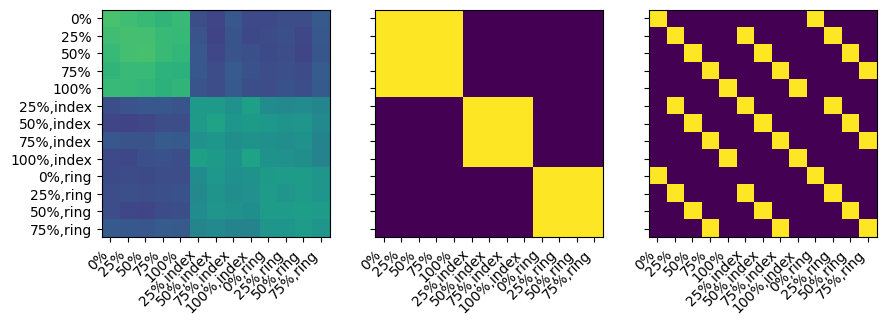

In [14]:
import PcmPy as pcm

snS = [102, 103, 104]

experiment = 'smp2'
Hem = 'L'
glm = 12
roi = 'PMd'

Z_stimFinger = np.zeros((13, 3))
Z_stimFinger[0:5, 0] = 1
Z_stimFinger[5:9, 1] = 1
Z_stimFinger[9:13, 2] = 1

Z_cue = np.zeros((13, 5))
Z_cue[[0,9], 0] = 1
Z_cue[[1,5,10], 1] = 1
Z_cue[[2,6,11], 2] = 1
Z_cue[[3,7,12], 3] = 1
Z_cue[[4,8], 4] = 1

N=len(snS)
G_hat_betas = np.zeros((N,13,13))
Y = list()
for s, sn in enumerate(snS):

    reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')

    betas = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.beta.npy'))
    res = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.res.npy'))

    betas_prewhitened = betas / res

    cond_vec = reginfo.name.str.replace(" ", "").map(gl.regressor_mapping)
    part_vec = reginfo.run

    obs_des = {'cond_vec': cond_vec,
               'part_vec': part_vec}

    Y.append(pcm.dataset.Dataset(betas_prewhitened, obs_descriptors=obs_des))

    G_hat_betas[s],_ = pcm.est_G_crossval(Y[s].measurements, Y[s].obs_descriptors['cond_vec'], Y[s].obs_descriptors['part_vec'], X=pcm.matrix.indicator(Y[s].obs_descriptors['part_vec']))

vmin = G_hat_betas.min()
vmax = G_hat_betas.max()

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 7))

axs[0].imshow(G_hat_betas.mean(axis=0),vmin=vmin,vmax=vmax)
axs[1].imshow(Z_stimFinger @ Z_stimFinger.T)
axs[2].imshow(Z_cue @ Z_cue.T)

for ax in axs:
    ax.set_xticks(np.arange(G_hat_betas.shape[1]))
    ax.set_yticks(np.arange(G_hat_betas.shape[2]))
    ax.set_xticklabels(gl.regressor_mapping.keys(), rotation=45, ha='right')
    ax.set_yticklabels(gl.regressor_mapping.keys(),  ha='right')

M = []
M.append(pcm.FixedModel('null',np.eye(13)))
M.append(pcm.FixedModel('stimFinger', Z_stimFinger @ Z_stimFinger.T))
M.append(pcm.FixedModel('cue', Z_cue @ Z_cue.T))
M.append(pcm.ComponentModel('stimFinger+cue',np.array([Z_stimFinger @ Z_stimFinger.T,Z_cue @ Z_cue.T])))
M.append(pcm.FreeModel('ceil',13)) # Noise ceiling model

T_in, theta_in = pcm.fit_model_individ(Y,M, fit_scale=True, verbose=True, fixed_effect='block')





variable     likelihood                                               \
model              null     stimFinger            cue stimFinger+cue   
0         224749.333981  225350.173715  224599.667432  225350.208912   
1         150302.707217  153867.441771  147397.027512  153867.455868   
2         168382.681389  173170.086810  163707.271253  173170.099739   

variable                    noise                                      \
model              ceil      null stimFinger       cue stimFinger+cue   
0         226738.500314  0.004826   0.004807  0.004972       0.004807   
1         154682.333645  0.024181   0.024061  0.027737       0.024061   
2         174702.810206  0.024633   0.024549  0.029250       0.024549   

variable           iterations                                           scale  \
model         ceil       null stimFinger   cue stimFinger+cue  ceil      null   
0         0.004609        4.0        5.0  14.0           17.0  80.0  0.000146   
1         0.023510        4.0 

<Axes: xlabel='model', ylabel='Log Bayes Factor'>

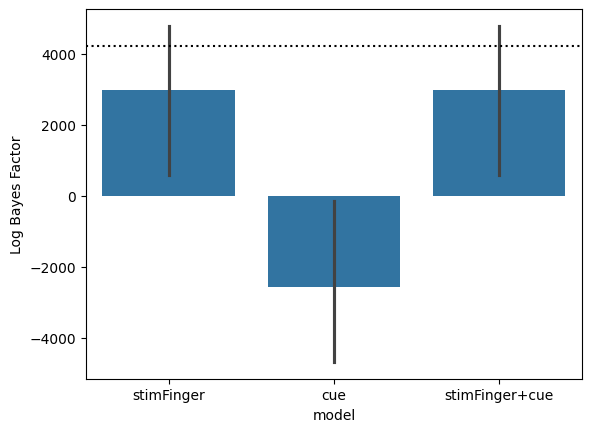

In [15]:
print(T_in)

pcm.model_plot(T_in.likelihood, null_model='null', noise_ceiling= 'ceil')